# **Veri Yükleme, Temizleme ve Ölçeklendirme**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Grafik ayarları
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

import warnings
warnings.filterwarnings('ignore')

# 1. Veri Setini Yükle ve Gereksiz Sütunları At
df = pd.read_csv("/content/Customer behaviour Tourism.csv")
df = df.drop('UserID', axis=1, errors='ignore')

# 2. Eksik Verileri Doldur (Sayısal: Medyan, Kategorik: Mod)
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# 3. Target (Hedef) ve Bağımsız Değişkenleri (X) Ayırma
le = LabelEncoder()
df['Taken_product'] = le.fit_transform(df['Taken_product']) # Yes: 1, No: 0

X = df.drop('Taken_product', axis=1)
y = df['Taken_product']

# 4. Kategorik Değişkenleri Sayısallaştırma (One-Hot Encoding)
X = pd.get_dummies(X, drop_first=True)

# 5. Train/Test Bölünmesi (%80 Eğitim, %20 Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 6. Özellik Ölçeklendirme (KNN için KRİTİK ADIM!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("="*50)
print("⚙️ VERİ ÖN İŞLEME TAMAMLANDI!")
print("="*50)
print(f"Eğitim Seti Boyutu: {X_train_scaled.shape}")
print(f"Test Seti Boyutu: {X_test_scaled.shape}")
print("Veriler standartlaştırıldı (Mean=0, Std=1). Modellere hazırız.")

⚙️ VERİ ÖN İŞLEME TAMAMLANDI!
Eğitim Seti Boyutu: (9408, 73)
Test Seti Boyutu: (2352, 73)
Veriler standartlaştırıldı (Mean=0, Std=1). Modellere hazırız.


# **KNN Algoritması İçin En İyi 'K' Değerini Bulma (Dirsek / Elbow Metodu)**

🔍 KNN İÇİN OPTİMUM 'K' DEĞERİNİ BULMA (ELBOW METHOD)


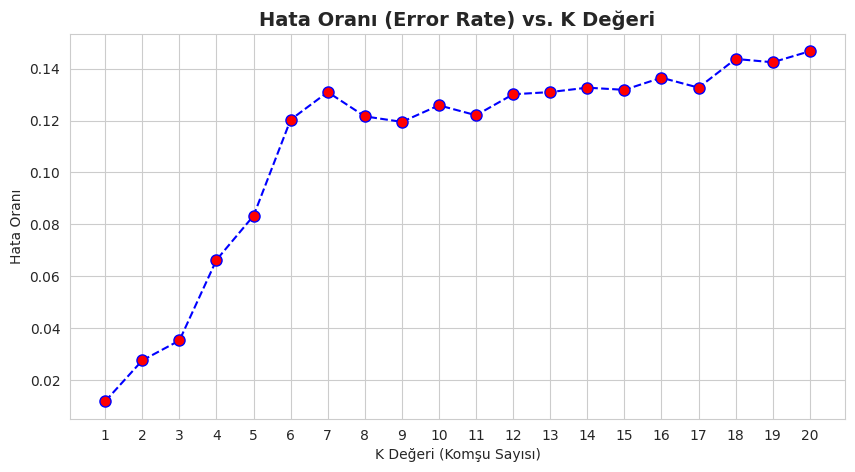

💡 GRAFİK YORUMU: Hata oranının en düşük olduğu K değeri 1 olarak görünüyor. Modelimizi bu değerle kuracağız.


In [ ]:
print("="*50)
print("🔍 KNN İÇİN OPTİMUM 'K' DEĞERİNİ BULMA (ELBOW METHOD)")
print("="*50)

hata_oranlari = []

# K değerini 1'den 20'ye kadar deneyelim
for i in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_scaled, y_train)
    pred_i = knn.predict(X_test_scaled)
    # Hata oranı: Gerçek değerle eşleşmeyenlerin ortalaması
    hata_oranlari.append(np.mean(pred_i != y_test))

# Grafiği Çizdir
plt.figure(figsize=(10, 5))
plt.plot(range(1, 21), hata_oranlari, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=8)
plt.title('Hata Oranı (Error Rate) vs. K Değeri', fontweight='bold', fontsize=14)
plt.xlabel('K Değeri (Komşu Sayısı)')
plt.ylabel('Hata Oranı')
plt.xticks(range(1, 21))
plt.show()

# En düşük hataya sahip K'yı otomatik bulma
en_iyi_k = hata_oranlari.index(min(hata_oranlari)) + 1
print(f"💡 GRAFİK YORUMU: Hata oranının en düşük olduğu K değeri {en_iyi_k} olarak görünüyor. Modelimizi bu değerle kuracağız.")

# **KNN ve Naive Bayes Modellerini Eğitme**

In [ ]:
print("="*50)
print("🤖 MODELLER EĞİTİLİYOR...")
print("="*50)

# 1. KNN MODELİ (Bulduğumuz en iyi K değeri ile)
knn_model = KNeighborsClassifier(n_neighbors=en_iyi_k)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)
acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"✅ KNN Eğitildi! Doğruluk (Accuracy): % {acc_knn*100:.2f}")

# 2. NAIVE BAYES MODELİ (GaussianNB - Sürekli veriler için uygundur)
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)
y_pred_nb = nb_model.predict(X_test_scaled)
acc_nb = accuracy_score(y_test, y_pred_nb)
print(f"✅ Naive Bayes Eğitildi! Doğruluk (Accuracy): % {acc_nb*100:.2f}")

🤖 MODELLER EĞİTİLİYOR...
✅ KNN Eğitildi! Doğruluk (Accuracy): % 98.81
✅ Naive Bayes Eğitildi! Doğruluk (Accuracy): % 22.53


# **Karşılaştırmalı Performans Analizi (Görsel Rapor)**

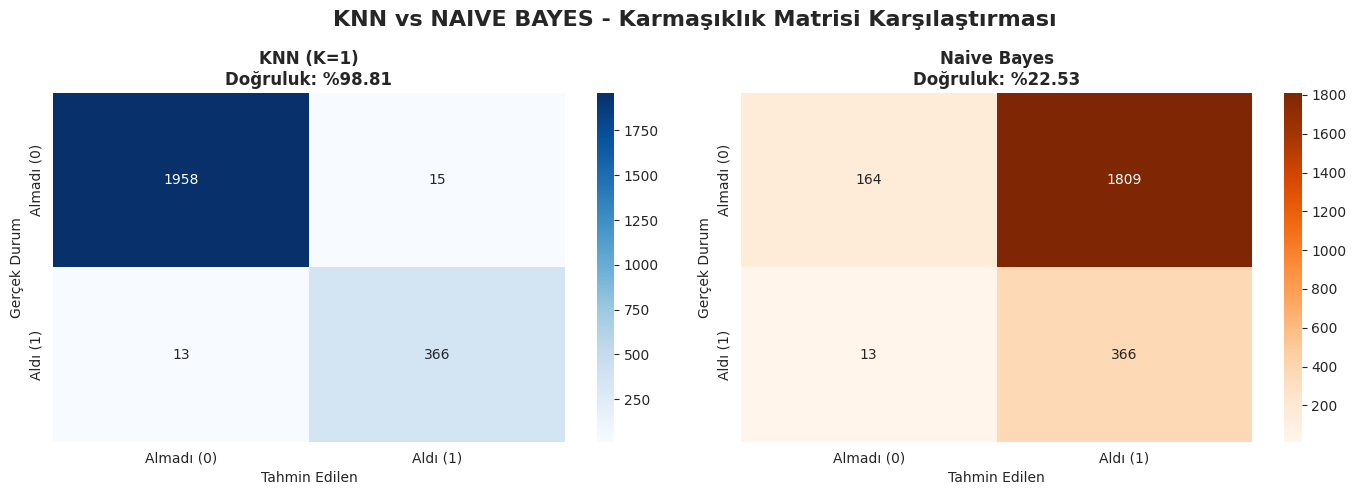

📊 DETAYLI SINIFLANDIRMA RAPORLARI
--- KNN RAPORU ---
              precision    recall  f1-score   support

  Almadı (0)       0.99      0.99      0.99      1973
    Aldı (1)       0.96      0.97      0.96       379

    accuracy                           0.99      2352
   macro avg       0.98      0.98      0.98      2352
weighted avg       0.99      0.99      0.99      2352


--- NAIVE BAYES RAPORU ---
              precision    recall  f1-score   support

  Almadı (0)       0.93      0.08      0.15      1973
    Aldı (1)       0.17      0.97      0.29       379

    accuracy                           0.23      2352
   macro avg       0.55      0.52      0.22      2352
weighted avg       0.80      0.23      0.17      2352



In [ ]:
# Confusion Matrixleri Oluştur
cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_nb = confusion_matrix(y_test, y_pred_nb)

# Yan yana iki grafik çiz
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('KNN vs NAIVE BAYES - Karmaşıklık Matrisi Karşılaştırması', fontweight='bold', fontsize=16)

# KNN Grafiği
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Almadı (0)', 'Aldı (1)'], yticklabels=['Almadı (0)', 'Aldı (1)'])
axes[0].set_title(f'KNN (K={en_iyi_k})\nDoğruluk: %{acc_knn*100:.2f}', fontweight='bold')
axes[0].set_xlabel('Tahmin Edilen')
axes[0].set_ylabel('Gerçek Durum')

# Naive Bayes Grafiği
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Almadı (0)', 'Aldı (1)'], yticklabels=['Almadı (0)', 'Aldı (1)'])
axes[1].set_title(f'Naive Bayes\nDoğruluk: %{acc_nb*100:.2f}', fontweight='bold')
axes[1].set_xlabel('Tahmin Edilen')
axes[1].set_ylabel('Gerçek Durum')

plt.tight_layout()
plt.show()

print("="*50)
print("📊 DETAYLI SINIFLANDIRMA RAPORLARI")
print("="*50)
print("--- KNN RAPORU ---")
print(classification_report(y_test, y_pred_knn, target_names=['Almadı (0)', 'Aldı (1)']))
print("\n--- NAIVE BAYES RAPORU ---")
print(classification_report(y_test, y_pred_nb, target_names=['Almadı (0)', 'Aldı (1)']))

# **Sonuç ve İş Dünyası Yorumu**

In [ ]:
print("="*60)
print("🏆 SONUÇ VE İŞ DÜNYASI (BUSINESS) YORUMU")
print("="*60)

kazanan = "KNN" if acc_knn > acc_nb else "Naive Bayes"

print(f"Genel Doğruluk (Accuracy) açısından kazanan algoritma: ** {kazanan} **\n")

print("💡 BİLİMSEL YORUM:")
print("1. KNN'nin Avantajı: Müşteriler arasında gruplaşmalar (kümeler) varsa, mesafe tabanlı olduğu için bunu çok iyi yakalar. Ancak One-Hot Encoding ile sütun sayısı çok arttığı için bazen 'Boyutluluk Laneti'ne (Curse of Dimensionality) kurban gidebilir.")
print("2. Naive Bayes'in Avantajı: Müşteri özelliklerinin birbirinden bağımsız olduğunu varsayar. Hızlıdır ve az veriyle bile iyi olasılık hesaplar. Ancak 'Yaş' ve 'Gelir' gibi birbiriyle bağlantılı veriler varsa performansı düşebilir.\n")

print("🎯 PAZARLAMA EKİBİ İÇİN STRATEJİ:")
print(f"Elde ettiğimiz %{max(acc_knn, acc_nb)*100:.2f} başarı oranı ile, yeni gelen bir müşterinin profiline bakarak turizm paketini alıp almayacağını önceden tahmin edebiliriz.")
print("Eğer model 'Alacak' (1) derse, bu kişilere özel indirim e-postaları veya SMS atarak satış dönüşüm oranlarımızı (Conversion Rate) ciddi oranda artırabiliriz.")

🏆 SONUÇ VE İŞ DÜNYASI (BUSINESS) YORUMU
Genel Doğruluk (Accuracy) açısından kazanan algoritma: ** KNN **

💡 BİLİMSEL YORUM:
1. KNN'nin Avantajı: Müşteriler arasında gruplaşmalar (kümeler) varsa, mesafe tabanlı olduğu için bunu çok iyi yakalar. Ancak One-Hot Encoding ile sütun sayısı çok arttığı için bazen 'Boyutluluk Laneti'ne (Curse of Dimensionality) kurban gidebilir.
2. Naive Bayes'in Avantajı: Müşteri özelliklerinin birbirinden bağımsız olduğunu varsayar. Hızlıdır ve az veriyle bile iyi olasılık hesaplar. Ancak 'Yaş' ve 'Gelir' gibi birbiriyle bağlantılı veriler varsa performansı düşebilir.

🎯 PAZARLAMA EKİBİ İÇİN STRATEJİ:
Elde ettiğimiz %98.81 başarı oranı ile, yeni gelen bir müşterinin profiline bakarak turizm paketini alıp almayacağını önceden tahmin edebiliriz.
Eğer model 'Alacak' (1) derse, bu kişilere özel indirim e-postaları veya SMS atarak satış dönüşüm oranlarımızı (Conversion Rate) ciddi oranda artırabiliriz.
